In [1]:
library(stats)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(car)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




# Model is correctly specified


## Omitted variables


In [2]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 5, sd = 2)
x2 <- rpois(n, lambda = 10)
x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) + (1.5 * x2) + (3 * x3) + rnorm(n, mean = 0, sd = 2) # The observed data is a function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)


,x1,x2,x3,y
,<dbl>,<int>,<int>,<dbl>
1,3.747092,8,0,18.71413
2,5.367287,10,1,30.55495
3,3.328743,7,1,19.72848
4,8.190562,6,0,27.53913
5,5.659016,15,2,43.43831
6,3.359063,12,2,37.12327


In [3]:
model1 <- lm(formula = y ~ x1, data = df)
summary(model1)



Call:
lm(formula = y ~ x1, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.5466  -4.5349  -0.5704   3.7807  17.8914 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   19.581      1.892  10.351  < 2e-16 ***
x1             2.208      0.343   6.439 4.48e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.13 on 98 degrees of freedom
Multiple R-squared:  0.2973,	Adjusted R-squared:  0.2901 
F-statistic: 41.46 on 1 and 98 DF,  p-value: 4.48e-09


In [4]:
model2 <- lm(formula = y ~ x1 + x2, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.9908 -2.8250 -0.2765  2.7339  9.2147 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.1121     1.5821   3.863 0.000202 ***
x1            2.0313     0.2124   9.563 1.18e-15 ***
x2            1.4977     0.1185  12.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.788 on 97 degrees of freedom
Multiple R-squared:  0.7344,	Adjusted R-squared:  0.7289 
F-statistic: 134.1 on 2 and 97 DF,  p-value: < 2.2e-16


In [5]:
model3 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.9908 -2.8250 -0.2765  2.7339  9.2147 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.1121     1.5821   3.863 0.000202 ***
x1            2.0313     0.2124   9.563 1.18e-15 ***
x2            1.4977     0.1185  12.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.788 on 97 degrees of freedom
Multiple R-squared:  0.7344,	Adjusted R-squared:  0.7289 
F-statistic: 134.1 on 2 and 97 DF,  p-value: < 2.2e-16


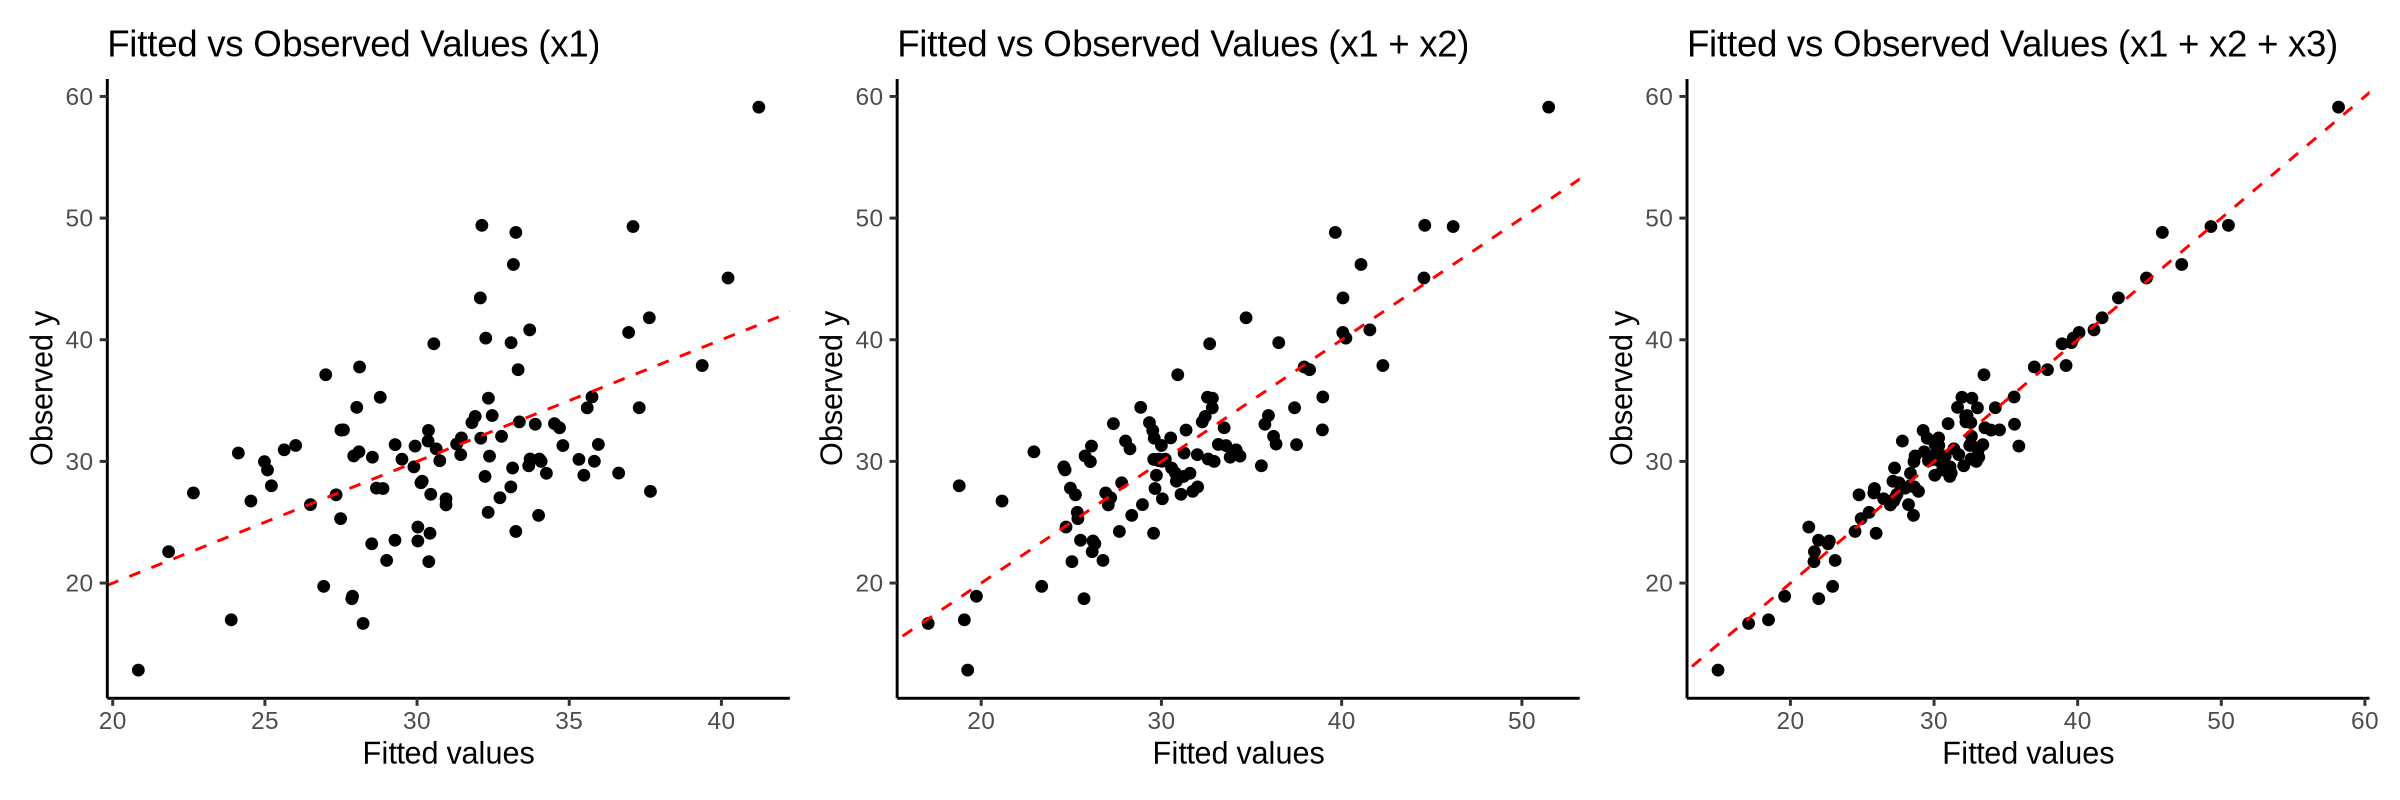

In [7]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

df$fitted <- fitted(model1)
plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1)") +
    theme_classic()

df$fitted <- fitted(model2)
plt2 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2)") +
    theme_classic()

df$fitted <- fitted(model3)
plt3 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2 + x3)") +
    theme_classic()

plt1 + plt2 + plt3


- If the fitted values correlate well with the observed values, the model is more likely to not omit important variables


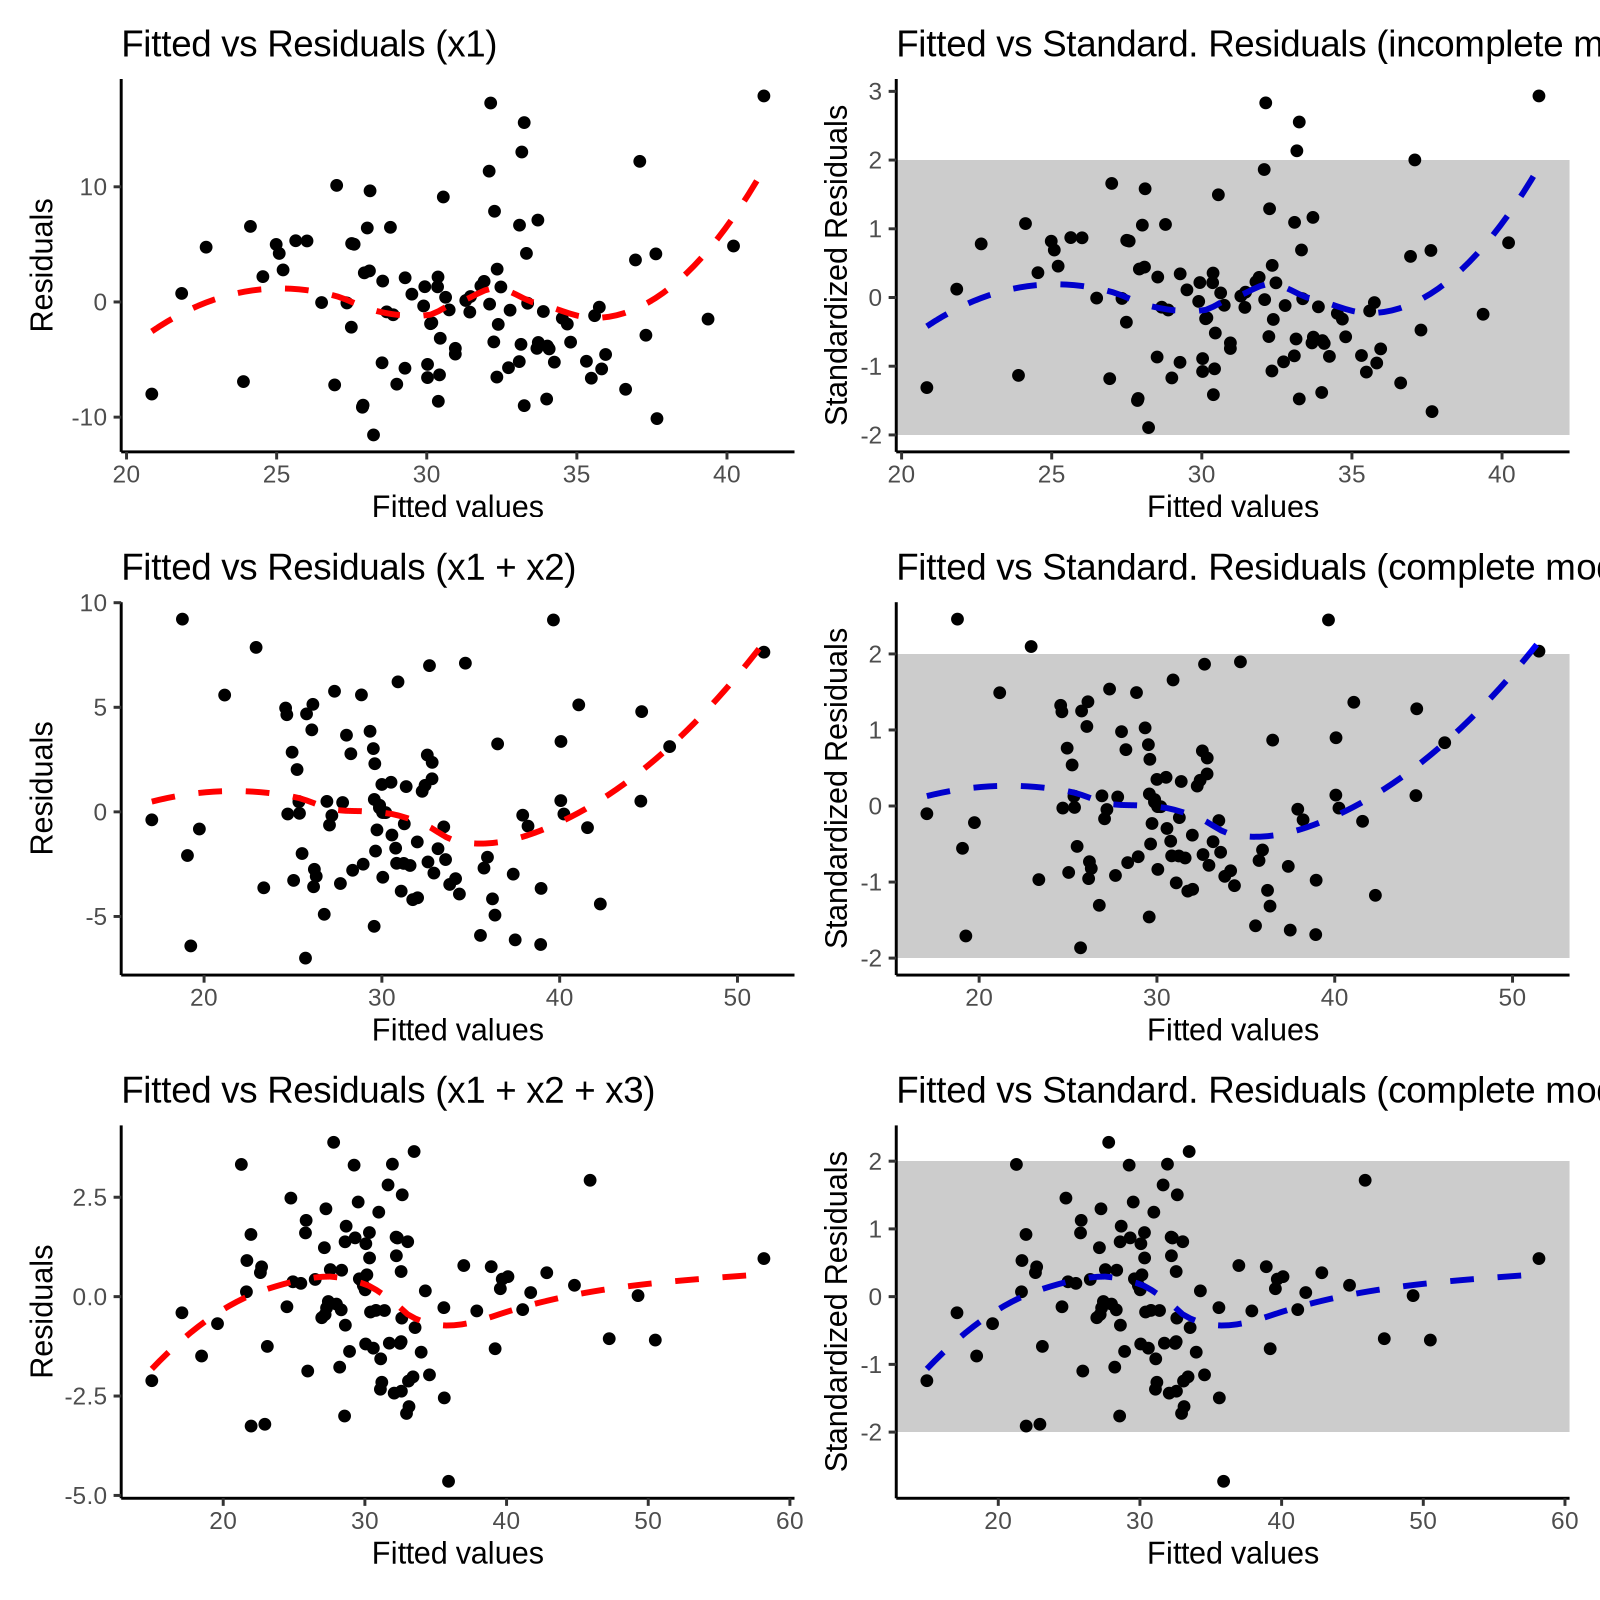

In [8]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()


df$fitted <- fitted(model3)
df$residuals <- residuals(model3)
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2 + x3)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


- The residuals are much smaller overall in the complete model, and the lowess follows closer to 0
- but without knowing the real data it would be difficult to say if the incomplete model explains most of the effect just by those plots


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 1.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 1”


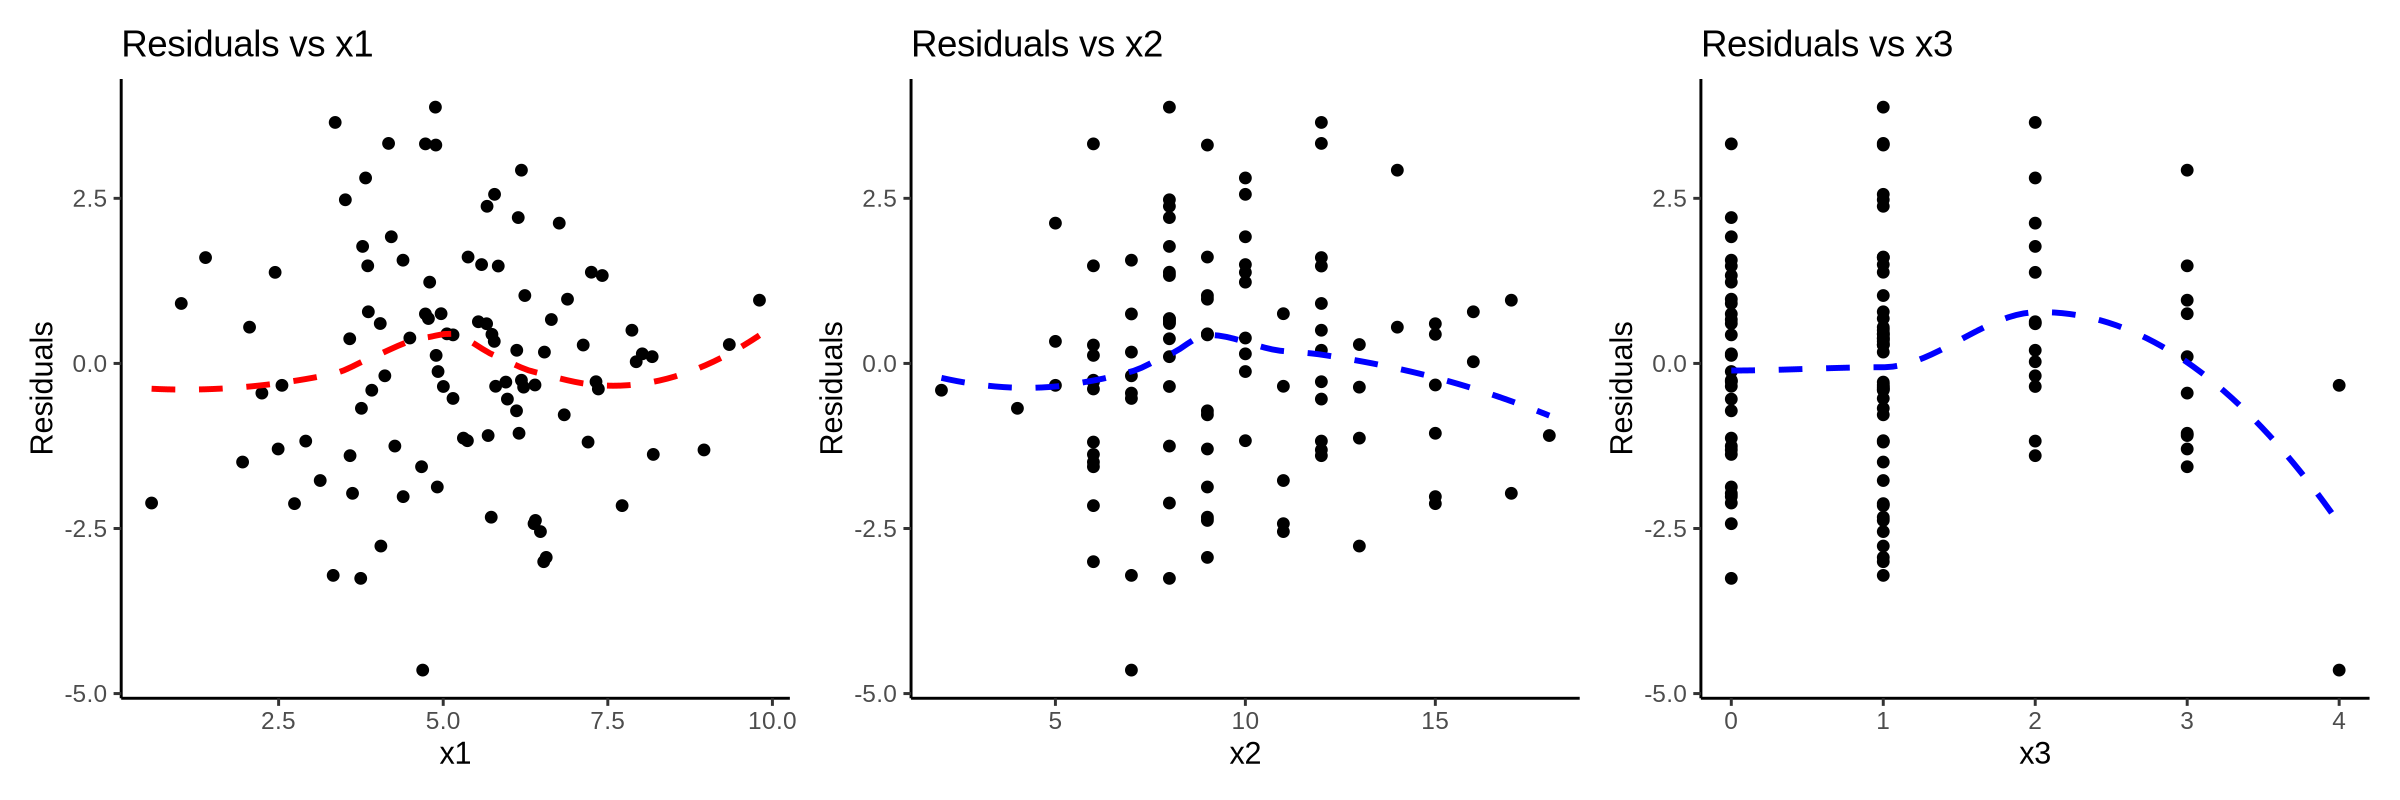

In [10]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

plt_x1 <- ggplot(df, aes(x = x1, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "x1", y = "Residuals", title = "Residuals vs x1") +
    theme_classic()

plt_x2 <- ggplot(df, aes(x = x2, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x2", y = "Residuals", title = "Residuals vs x2") +
    theme_classic()

plt_x3 <- ggplot(df, aes(x = x3, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x3", y = "Residuals", title = "Residuals vs x3") +
    theme_classic()

plt_x1 + plt_x2 + plt_x3
